In [1]:
import qutip as qt
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt
import scipy.linalg as la

fit exponents: [-2.30579486+3.0415718j -2.30579486-3.0415718j -0.86700042+0.j
 -0.05810885+0.j       ]
fit Residues: [0.22084228-2.18454216e-01j 0.22084228+2.18454216e-01j
 0.31782625-1.11022302e-16j 0.07067238-8.32667268e-17j]
fit error: 0.16753069052383962 



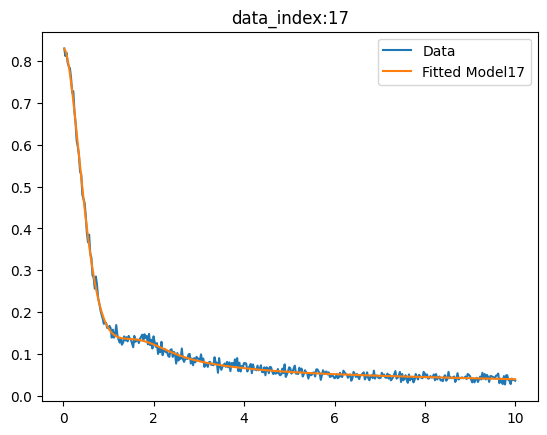

In [201]:
"""
Matrix Pencil Method for exponential signal decomposition.

This script extracts exponential poles and residues from experimental
time-domain data using the matrix pencil method (MPM).

Steps:
1. Construct Hankel matrix from time-series data
2. Perform SVD to separate signal and noise subspaces
3. Solve the matrix pencil eigenvalue problem to obtain poles
4. Convert poles to continuous-time exponents
5. Estimate residues via least-squares fitting
"""

# loading the data
sample_points =400
h5_plotting_file = os.path.join('parametric_drive_T1_plotting_data.h5')
ds = xr.load_dataset(h5_plotting_file)
state_data_matrix = ds['state_data_2d'].values
tlist = ds['time'].values[:sample_points]/800
data_index = 17
y_data = state_data_matrix[data_index][:sample_points]

# Matrix Pencil Method for extracting exponents
N = len(y_data)
L = N//2
dt = tlist[1] - tlist[0]
Y = np.array([ [y_data[i+j] for j in range(L+1)] for i in range(N-L)])
U,s,Vh = la.svd(Y, full_matrices = False)

threshold = 0.02
s_filtered = s[s/s[0] > threshold]
M = len(s_filtered)
#M = 2
V = Vh.conj().T
V_filtered = V[:, :M]
V1 = V_filtered[:-1, :]
V2 = V_filtered[1: , :]
V1h = V1.conj().T
V2h = V2.conj().T

Z = la.pinv(V1h) @ V2h # matrix pencil operator
eigvals = la.eigvals(Z)
eigvals = eigvals[ np.abs(eigvals) > 1e-3]
exponents = np.log(eigvals) / dt
#exponents = exponents[ np.real(exponents) < 0] # filter out positive exponents
print("fit exponents:",exponents)

# Finding Residues
Z = np.zeros((N, M), dtype=complex) # matrix pencil operator
for i in range(M):
    Z[:, i] = np.exp(exponents[i] * tlist)
R, _, _, _ = la.lstsq(Z, y_data)
print("fit Residues:", R)

# the fitted model
y_fit = Z @ R
error = np.linalg.norm(y_data - y_fit)
print("fit error:", error,"\n")

# Plotting the results
plt.title("data_index:"+str(data_index))
#plt.yscale("log")
plt.plot( tlist, np.real(y_data), label='Data')
plt.plot( tlist, np.real(y_fit), label='Fitted Model'+str(data_index))
plt.legend()

# eigenvalues verses index

Text(0, 0.5, 'imag(exponent)')

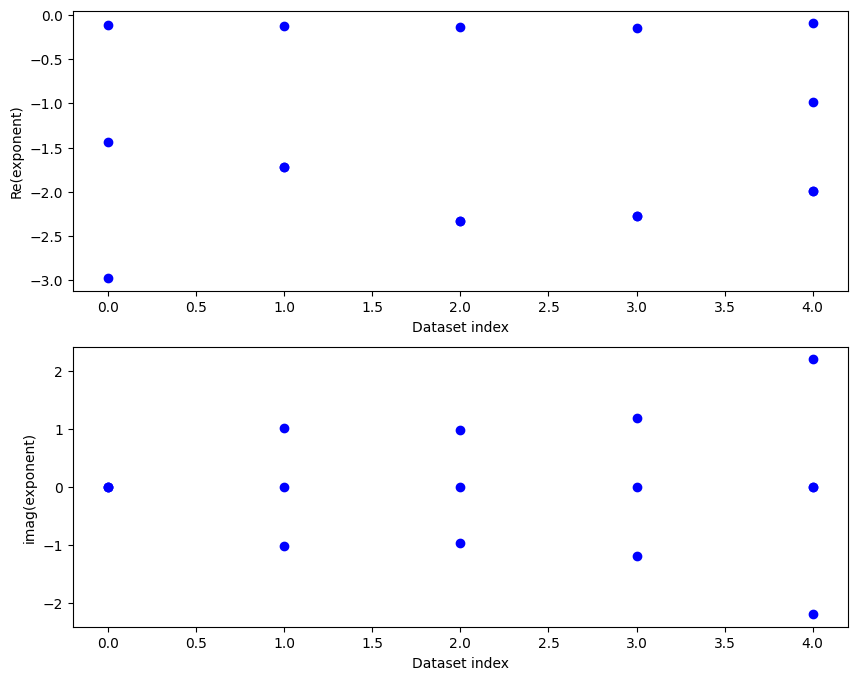

In [204]:
# loading the data
h5_plotting_file = os.path.join('parametric_drive_T1_plotting_data.h5')
ds = xr.load_dataset(h5_plotting_file)
state_data_matrix = ds['state_data_2d'].values
#sample_points = 300

tlist = ds['time'].values/800

poles = []
for data_index in range(10,15):#range(20): #range(len(state_data_matrix)):
    y_data = state_data_matrix[data_index]
    
    # Matrix Pencil Method for extracting exponents
    N = len(y_data)
    L = N//2
    dt = tlist[1] - tlist[0]
    Y = np.array([ [y_data[i+j] for j in range(L+1)] for i in range(N-L)])
    U,s,Vh = la.svd(Y, full_matrices = False)
    
    threshold = 0.016
    s_filtered = s[s/s[0] > threshold]
    M = len(s_filtered)
    #M = 4
    V = Vh.conj().T
    V_filtered = V[:, :M]
    V1 = V_filtered[:-1, :]
    V2 = V_filtered[1: , :]
    V1h = V1.conj().T
    V2h = V2.conj().T
    
    Z = la.pinv(V1h) @ V2h
    eigvals = la.eigvals(Z)
    eigvals = eigvals[np.abs(eigvals) > 1e-3]
    exponents = np.log(eigvals) / dt
    #exponents = exponents[ np.real(exponents) < 0] # filter out positive exponents
    poles.append(exponents)

    # Finding Residues
    Z = np.zeros((N, M), dtype=complex)
    for i in range(M):
        Z[:, i] = np.exp(exponents[i] * tlist)
    R, _, _, _ = la.lstsq(Z, y_data)

    # the fitted model
    y_fit = Z @ R
    #plt.yscale("log")
    # plt.subplot(2,1,1)
    # plt.plot(tlist, np.real(y_fit))
    # plt.plot(tlist, np.real(y_data))

plt.figure(figsize=(10, 8))
plt.subplot(2,1,1)
for i, exps in enumerate(poles):
    for e in exps:
        plt.scatter(i, np.real(e), color='blue')
plt.xlabel("Dataset index")
plt.ylabel("Re(exponent)")

plt.subplot(2,1,2)
for i, exps in enumerate(poles):
    for e in exps:
        plt.scatter(i, np.imag(e), color='blue')
plt.xlabel("Dataset index")
plt.ylabel("imag(exponent)")

In [167]:
exponents

array([-2.92941695+0.j, -1.17747306+0.j])